# Customer Churn Prediction in Telecom Industry

## Week 2

### import necessary libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')


In [39]:
df = pd.read_csv('telco_data.csv') 

In [40]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [41]:
df.shape

(7043, 21)

### null values

In [42]:
df.isnull().sum()

customerID             0
gender               750
SeniorCitizen          0
Partner             1000
Dependents             0
tenure              2500
PhoneService           0
MultipleLines          0
InternetService     1000
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1500
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1500
TotalCharges           0
Churn                  0
dtype: int64

In [43]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,4543.000000,5543.000000
mean,0.162147,32.546555,64.876403
std,0.368612,24.505519,30.101331
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.750000
50%,0.000000,29.000000,70.550000
75%,0.000000,56.000000,89.925000
max,1.000000,72.000000,118.600000


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            6293 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           6043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            4543 non-null   float64
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   6043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       5543 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [45]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].dtypes)

float64


## Week 3 

### The Cleaning Sprint. Handling Missing Values (Imputation strategies) and Outlier Detection (Boxplots/Z-score).

In [46]:
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)


In [47]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


In [48]:
print(df.isnull().sum())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [49]:
print(df['SeniorCitizen'].astype('object'))

0       0
1       0
2       0
3       0
4       0
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: SeniorCitizen, Length: 7043, dtype: object


### Boxplot

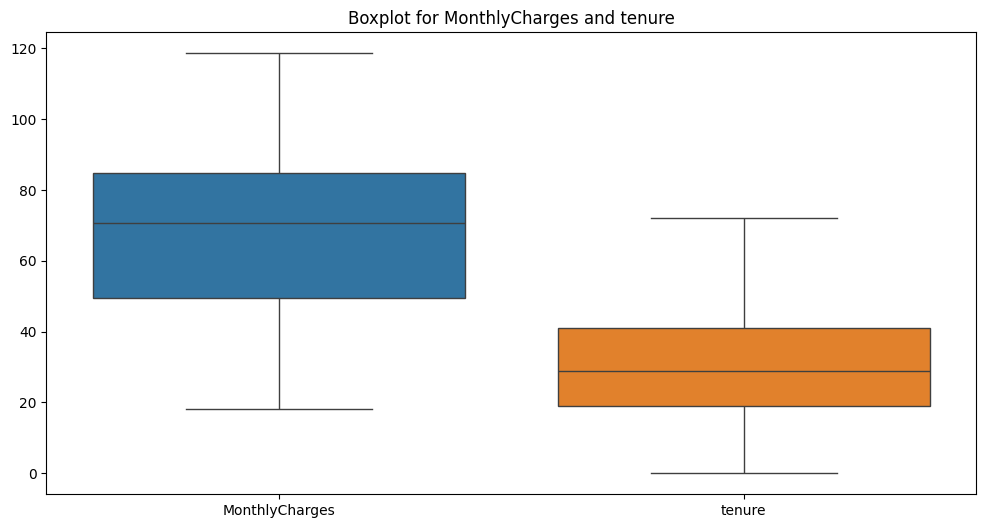

In [50]:
plt.figure(figsize=(12,6))

sns.boxplot(df[['MonthlyCharges','tenure']])

plt.title("Boxplot for MonthlyCharges and tenure")

plt.show()


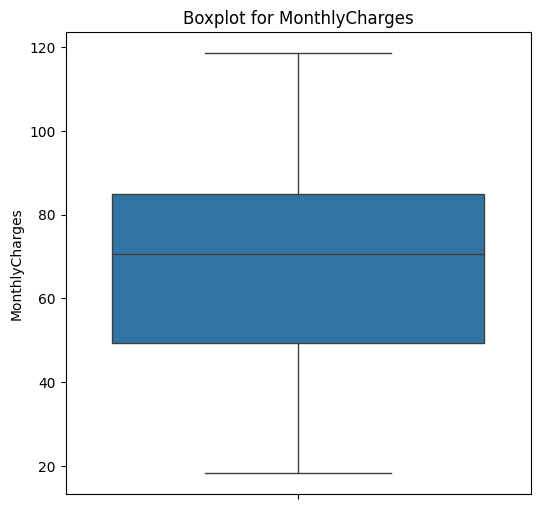

In [51]:
plt.figure(figsize=(6,6))
sns.boxplot(df['MonthlyCharges'])
plt.title("Boxplot for MonthlyCharges")
plt.show()

In [52]:
column = ['MonthlyCharges','tenure','TotalCharges']


In [53]:
df_zscore = df[column].apply(zscore)
print(df_zscore.head(10))




   MonthlyCharges    tenure  TotalCharges
0       -1.351911 -1.533375     -0.994242
1       -0.340816  0.137318     -0.173244
2       -0.456476 -1.482748     -0.959674
3       -0.887404  0.694215     -0.194766
4        0.172194 -1.482748     -0.940470
5        1.252312 -1.178985     -0.645186
6        0.858694 -0.470207     -0.146799
7       -1.355642 -1.077731     -0.874137
8        0.166598 -0.115818      0.337349
9       -0.370663  1.554875      0.532439


In [54]:
outliers = df[(df_zscore.abs() > 3).any(axis=1)]

print("Number of outliers:", len(outliers))


Number of outliers: 0


### we dont have outlier in the dataset

## Week 4

## EDA

### Churn analysis

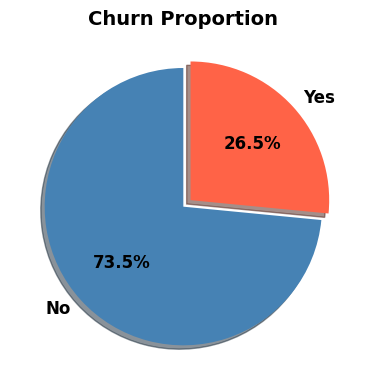

In [55]:
import matplotlib.pyplot as plt

churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(4,4))

plt.pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['steelblue', 'tomato'],
    explode=(0, 0.07),
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title('Churn Proportion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

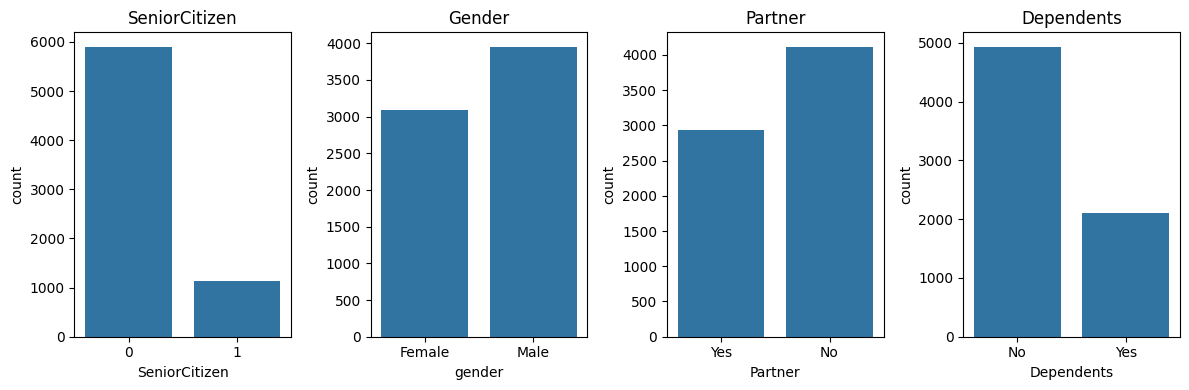

In [56]:
plt.figure(figsize=(12,4))

# SeniorCitizen
plt.subplot(1,4,1)
sns.countplot(x='SeniorCitizen', data=df)
plt.title("SeniorCitizen")

# Gender
plt.subplot(1,4,2)
sns.countplot(x='gender', data=df)
plt.title("Gender")

# Partner
plt.subplot(1,4,3)
sns.countplot(x='Partner', data=df)
plt.title("Partner")

plt.subplot(1,4,4)
sns.countplot(x='Dependents', data=df)
plt.title("Dependents")



plt.tight_layout()
plt.show()

### Churn based on gender

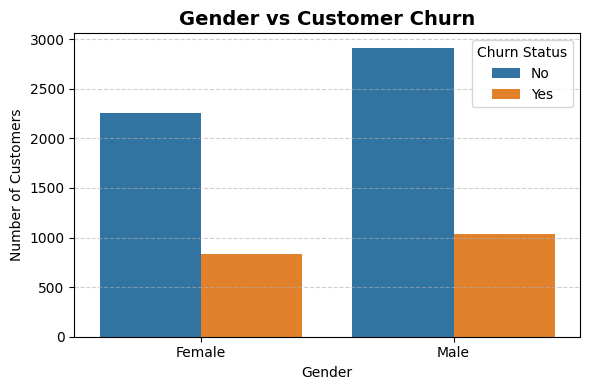

In [57]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='gender',
    hue='Churn',
    data=df
)

plt.title("Gender vs Customer Churn", fontsize=14, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.legend(title="Churn Status")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Churn based on partner

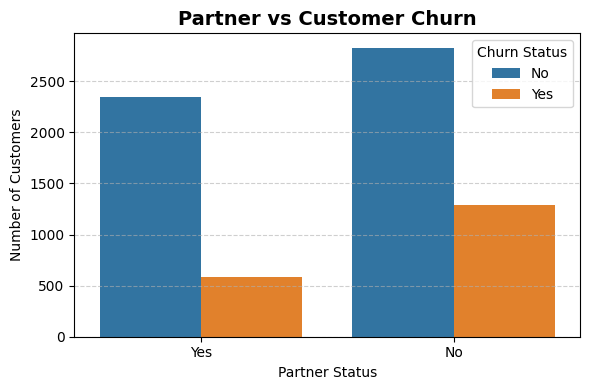

In [58]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Partner',
    hue='Churn',
    data=df
)

plt.title("Partner vs Customer Churn", fontsize=14, fontweight='bold')
plt.xlabel("Partner Status")
plt.ylabel("Number of Customers")

plt.legend(title="Churn Status")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Churn based on Tenure

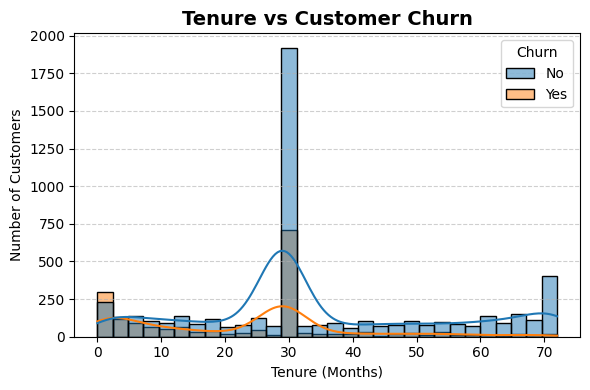

In [59]:
plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    bins=30,
    kde=True
)

plt.title("Tenure vs Customer Churn", fontsize=14, fontweight='bold')
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

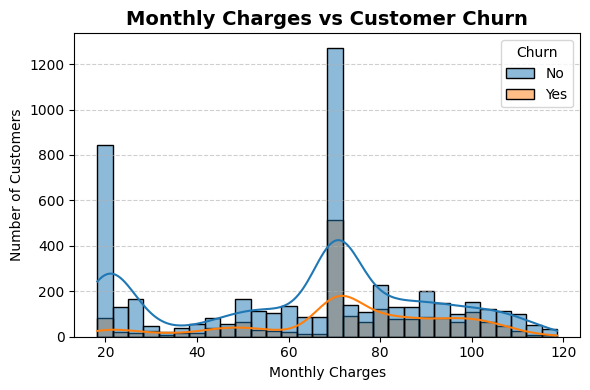

In [60]:
plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x='MonthlyCharges',
    hue='Churn',
    bins=30,
    kde=True
)

plt.title("Monthly Charges vs Customer Churn", fontsize=14, fontweight='bold')
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

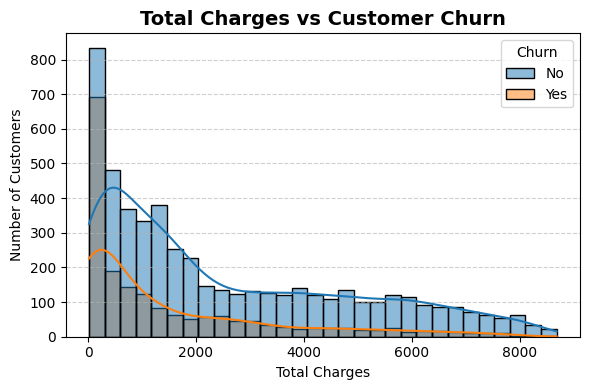

In [61]:
plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x='TotalCharges',
    hue='Churn',
    bins=30,
    kde=True
)

plt.title("Total Charges vs Customer Churn", fontsize=14, fontweight='bold')
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### senior citizen with gender

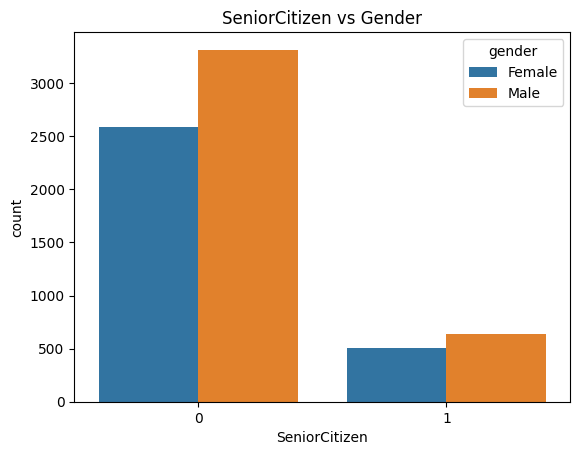

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='SeniorCitizen', hue='gender', data=df)

plt.title("SeniorCitizen vs Gender")
plt.show()

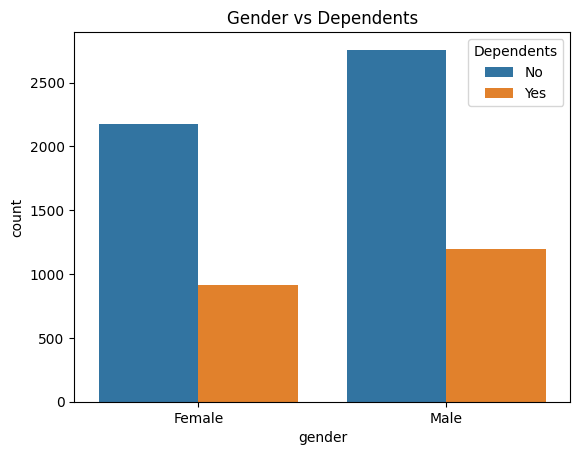

In [63]:
sns.countplot(x='gender', hue='Dependents', data=df)

plt.title("Gender vs Dependents")
plt.show()

In [64]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [65]:
num_df = df.select_dtypes(include=['int64', 'float64'])

In [66]:
corr_matrix = num_df.corr()

print(corr_matrix)

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges  \
SeniorCitizen        1.000000  0.004008        0.192526      0.102652   
tenure               0.004008  1.000000        0.221251      0.661536   
MonthlyCharges       0.192526  0.221251        1.000000      0.575482   
TotalCharges         0.102652  0.661536        0.575482      1.000000   
Churn                0.150889 -0.269223        0.167804     -0.199037   

                   Churn  
SeniorCitizen   0.150889  
tenure         -0.269223  
MonthlyCharges  0.167804  
TotalCharges   -0.199037  
Churn           1.000000  


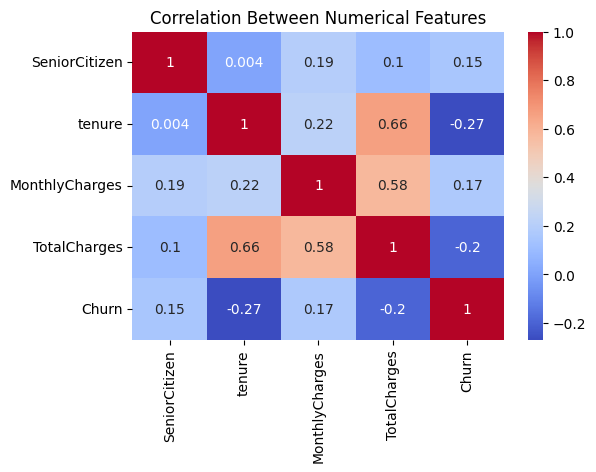

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Between Numerical Features")
plt.show()

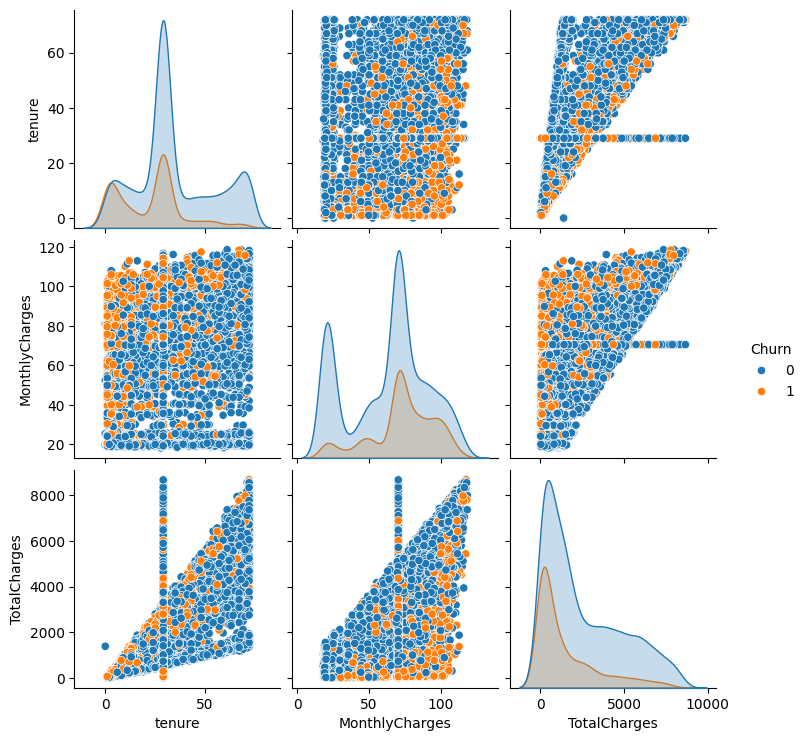

In [68]:
sns.pairplot(df[['tenure','MonthlyCharges','TotalCharges','Churn']], 
             hue='Churn')

plt.show()

### encoding

In [69]:
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0, 'Female':0, 'Male':1})

In [70]:
df.skew(numeric_only=True)

gender             -0.246398
SeniorCitizen       1.833633
Partner             0.342037
Dependents          0.875199
tenure              0.474282
PhoneService       -2.727153
PaperlessBilling   -0.375396
MonthlyCharges     -0.387201
TotalCharges        0.963789
Churn                    NaN
dtype: float64

### skewness

In [71]:
import numpy as np

df['TotalCharges'] = np.log1p(df['TotalCharges'])

In [72]:
df['TotalCharges'].skew()

-0.7445016135460701

### scaling

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['tenure','MonthlyCharges','TotalCharges']
df[num_cols] = scaler.fit_transform(df[num_cols])